In [1]:
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from pytorch_lightning.core.lightning import LightningModule
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')

from utils.config_dataset import *
from utils.ClassDataset import MergedDataset
from utils.ClassMonoModel import AE_PHYSIO, MED_PHYSIO_MONO
from utils.data_io import load_train_test_dataset

RANDOMSEED = 2024
torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

data_path = 'processed-merge-v3/'
norm_params = pickle.load(open(os.path.join(data_path, 'norm_params_vasopressor.p'), 'rb'))
norm_params_info = pickle.load(open(os.path.join(data_path, 'norm_params_info.p'), 'rb'))

def mae_loss(x_, x, los=False):
    if los:
        loss = np.mean(np.abs(x - x_))
    else:
        mask_valid = np.where(x!=-1)
        loss = np.mean(np.abs(x[mask_valid] - x_[mask_valid]))
    return loss

def de_norm(data, col, norm_params=norm_params):
    norm_min = norm_params[col].loc['0.1%']
    norm_max = norm_params[col].loc['99.9%']
    data_ = data * (norm_max - norm_min) + norm_min
    return data_

selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']

/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/pytorch_tcn/tcn.py:14: UserWarning: 
        The deprecated weight_norm from torch.nn.utils.weight_norm was imported.
        Update your PyTorch version to get rid of this warning.
        
  warnings.warn(


In [2]:
def plot_vital_pred(idx):
    sample = dataset_test[idx]
    x = sample['data']
    x[np.where(x==-1)] = np.nan
    x_ = X_reconstructed[idx]
    x_[np.where(x_==-1)] = np.nan
    x_next = X_pred[idx]
    x_next[np.where(x_next==-1)] = np.nan
    meds = ['dobutamine', 'epinephrine', 'norepinephrine']
    med_label = meds[np.where(sample['med_label']==1)[0].item()]
    x_med = sample['med']
    x_med[np.where(x_med==0)] = np.nan

    labels = selected_physio

#     fig = plt.figure(figsize=(16,8))
#     gs = fig.add_gridspec(8,3)
#     ax = []
#     for i in range(6):
#         if i == 0:
#             ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
            
        
#     ax.append(fig.add_subplot(gs[6:, :]))
    fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]
    for i, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)

        x_raw = de_norm(x[:,idx_physio], physio)
        x_pred = de_norm(x_next[:,idx_physio], physio)

        ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
        ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
        ax[i//3][i%3].set_title(f"{med_label} - {physio}")
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
    plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1)); 
    ax[1][2].set_xlim([0, 180])
    ax[1][2].set_xticks(np.arange(0, 180, 30))
    ax[1][2].set_xticklabels(np.arange(0, 360, 60))
    ax[1][0].set_xlabel('time [min]')
    ax[1][1].set_xlabel('time [min]')
    ax[1][2].set_xlabel('time [min]')

    fig, ax = plt.subplots(1, 1, figsize=(16,3))
    lines = []
    for med in MED_BENCHMARK[:3]:
        idx_med = MED_BENCHMARK.index(med)
        med_raw =  de_norm(x_med[:, idx_med], med)
        med_raw[np.where(med_raw==0)] = np.nan
        ax.plot(med_raw, label=med, color=colors(idx_med))
        lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
    ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));
    ax.set_xlim([0, 180])
    ax.set_xticks(np.arange(0, 180, 15))
    ax.set_xticklabels(np.arange(0, 360, 30))
    ax.set_xlabel('time [min]')
    return med_label, fig

In [3]:
def gridplot_vital_pred(idx):
    sample = dataset_test[idx]
    x = sample['data']
    x[np.where(x==-1)] = np.nan
    x_ = X_reconstructed[idx]
    x_[np.where(x_==-1)] = np.nan
    x_next = X_pred[idx]
    x_next[np.where(x_next==-1)] = np.nan
    meds = ['dobutamine', 'epinephrine', 'norepinephrine']
    med_label = meds[np.where(sample['med_label']==1)[0].item()]
    x_med = sample['med']
    x_med[np.where(x_med==0)] = np.nan

    labels = selected_physio

    fig = plt.figure(figsize=(16,10))
    gs = fig.add_gridspec(9,3)
    ax = []
    for i in range(6):
        if i == 0:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
        else:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
    ax.append(fig.add_subplot(gs[6:,:]))
    
    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]
    for i, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)

        x_raw = de_norm(x[:,idx_physio], physio)
        x_pred = de_norm(x_next[:,idx_physio], physio)

        ax[i].plot(range(180), x_raw, '-', color=colors(0))
        ax[i].plot(range(90, 180), x_pred, '--', color=colors(1))
        ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
    ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
    ax[5].set_xlim([0, 180])
    ax[5].set_xticks(np.arange(0, 180, 30))
    ax[5].set_xticklabels(np.arange(0, 360, 60))
#     ax[3].set_xlabel('time [min]')
#     ax[4].set_xlabel('time [min]')
#     ax[5].set_xlabel('time [min]')

    lines = []
    for med in MED_BENCHMARK[:3]:
        idx_med = MED_BENCHMARK.index(med)
        med_raw =  de_norm(x_med[:, idx_med], med)
        med_raw[np.where(med_raw==0)] = np.nan
        ax[6].plot(med_raw, label=med, color=colors(idx_med))
        lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
    ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
    ax[6].set_xlim([0, 180])
    ax[6].set_xticks(np.arange(0, 180, 15))
    ax[6].set_xticklabels(np.arange(0, 360, 30))
    ax[6].set_xlabel('time [min]')
    ax[6].set_title('Medication administration', fontsize=14)
    
    plt.subplots_adjust(hspace=2.5, wspace=.3)
    return med_label, fig

In [4]:
# load model
model_path_cnn = 'models/AE_PHYSIO/CNN-196hidden-0.1dropout-32-0.0005/version_0/'
model_file_cnn = os.path.join(model_path_cnn, 'epoch155-val_loss_pred0.04464.ckpt')
config_file_cnn = os.path.join(model_path_cnn, "model_config.p")
config_cnn = pickle.load(open(config_file_cnn, 'rb'))

model_path_tcn = 'models/AE_PHYSIO/TCN-168hidden-0.1dropout-32-0.0005/version_0/'
model_file_tcn = os.path.join(model_path_tcn, 'epoch244-val_loss_pred0.04329.ckpt')
config_file_tcn = os.path.join(model_path_tcn, "model_config.p")
config_tcn = pickle.load(open(config_file_tcn, 'rb'))

device = 'cuda'
model_cnn = AE_PHYSIO.load_from_checkpoint(checkpoint_path=model_file_cnn, config=config_cnn)
model_cnn.to(device)
model_cnn.eval()

model_tcn = AE_PHYSIO.load_from_checkpoint(checkpoint_path=model_file_tcn, config=config_tcn)
model_tcn.to(device)
model_tcn.eval()


# load data
pid_valid = pickle.load(open(os.path.join(data_path, 'pid_valid.p'), 'rb'))
patient_info = pickle.load(open(os.path.join(data_path, 'patient_info.p'), 'rb'))
sample_dict_control = pickle.load(open(os.path.join(data_path, 'sample_dict_control_filtered80.p'), 'rb'))
sample_dict_vaso = pickle.load(open(os.path.join(data_path, 'sample_dict_vasopressor_filtered80.p'), 'rb'))
# norm_params = pickle.load(open(os.path.join(data_path, 'norm_params_vasopressor.p'), 'rb'))
# norm_params_info = pickle.load(open(os.path.join(data_path, 'norm_params_info.p'), 'rb'))

# dischargestatus = []
# for i in sample_dict:
#     status = patient_info.loc[patient_info['patientid'] == sample_dict[i][1], 'discharge_status'].item()
#     label = 1 if status == 'dead' else 0
#     dischargestatus.append(label)
# dischargestatus = np.array(dischargestatus)

# selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
# selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']
# train_test_indices = pickle.load(open(os.path.join(data_path, 'train_test_split_vasopressor.p'), 'rb'))
# sampleid_train, sampleid_test = train_test_indices['train'], train_test_indices['test']
# sampleid_tr, sampleid_val = train_test_split(sampleid_train, test_size=0.2, random_state=RANDOMSEED,
#                                    stratify=dischargestatus[sampleid_train])

# dataset_val = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_val},
#                             df_info=patient_info, 
#                             norm=True, smooth=True, interpolate=True,
#                             selected_physio=selected_physio, selected_med=selected_med)
# dataset_test = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_test},
#                              df_info=patient_info, 
#                              norm=True, smooth=True, interpolate=True,
#                              selected_physio=selected_physio, selected_med=selected_med)
# loader_val = DataLoader(dataset_val, batch_size=16, shuffle=False, num_workers=32)
# loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False, num_workers=16)

DATA = load_train_test_dataset(
        batchsize=64,
        sample_dict_file='sample_dict_control_filtered80.p',
        type='control',
        RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True,
        data_path=data_path
    )
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
loader_train = DATA['loader_train']
loader_val = DATA['loader_val']
loader_test = DATA['loader_test']

Loading dataset
PID TRAIN: 3971, PID VAL: 993, PID TEST: 1241
SAMPLE TRAIN: 20429, SAMPLE VAL: 5041, SAMPLE TEST: 6628


In [10]:
X_reconstructed = []
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model_tcn(X)
    X_reconstructed.append(X_.cpu().detach().numpy())
    X_pred.append(X_next.cpu().detach().numpy())
    
X_reconstructed = np.concatenate(X_reconstructed, axis=0)
X_pred = np.concatenate(X_pred, axis=0)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 104/104 [00:30<00:00,  3.40it/s]


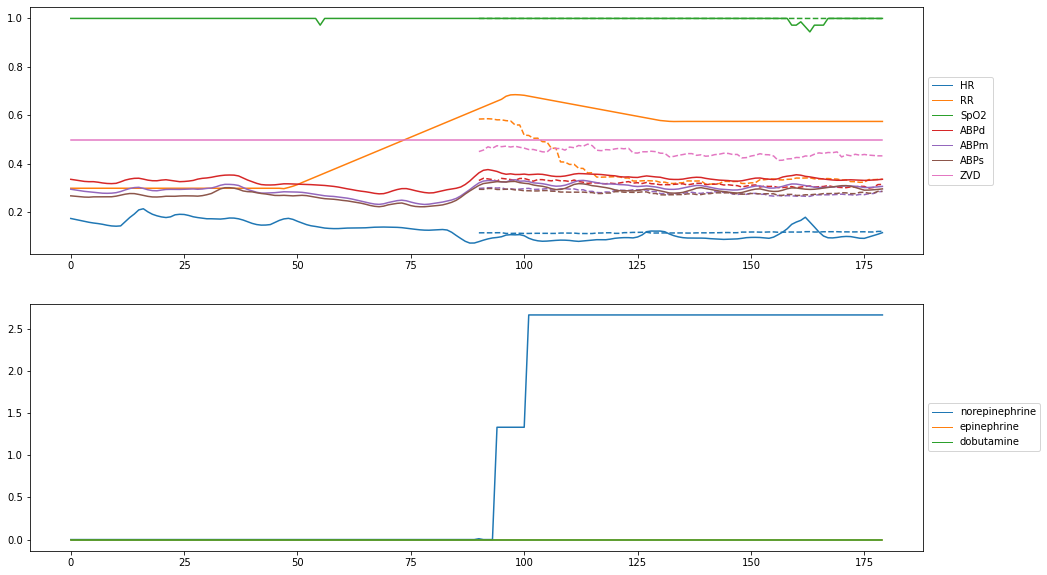

In [6]:
idx = 123
# idx = 15

x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
x_med = dataset_test[idx]['med']
x_med[np.where(x_med)==0] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,1,figsize=(16,10))
colors = plt.cm.tab10
for j in range(7):
    ax[0].plot(range(180), x[:,j], '-', color=colors(j))
#     ax.plot(range(90), x_[:,j], '--', color=colors(j))
    ax[0].plot(range(90, 180), x_next[:,j], '--', color=colors(j))

lines = [Line2D([0], [0], color=colors(i), lw=1, label=labels[i]) for i in range(7)]
ax[0].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));


lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax[1].plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax[1].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

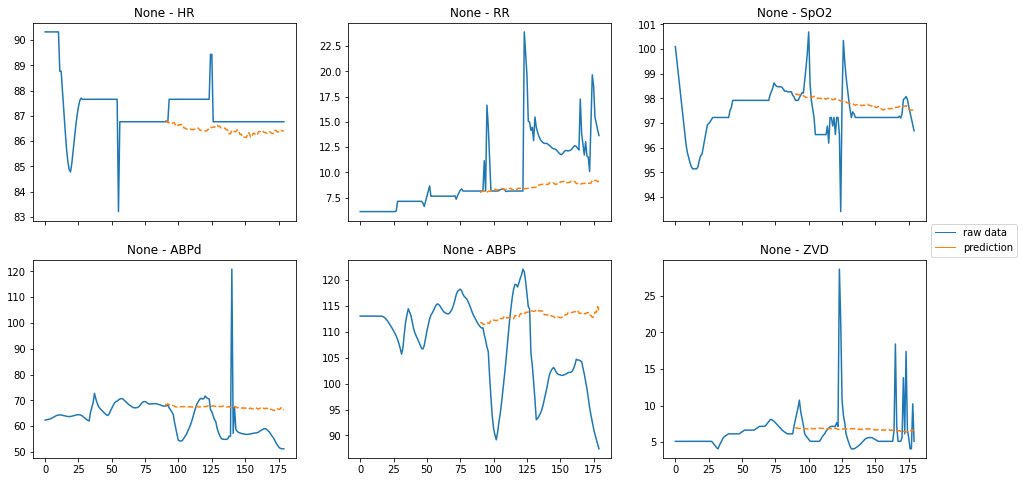

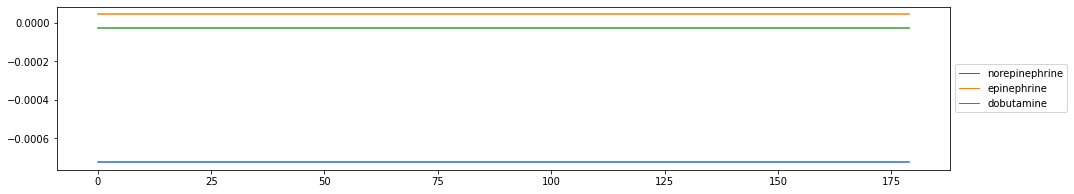

In [22]:
# idx = 30
# idx = 66
# idx = 15
idx = 33


x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
meds = ['dobutamine', 'epinephrine', 'norepinephrine']
try:
    med = meds[np.where(dataset_test[idx]['med_label']==1)[0].item()]
except:
    med = None
x_med = dataset_test[idx]['med']
x_med[np.where(x_med==0)] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPd',
    'ABPs',
    'ZVD',
]
for i, physio in enumerate(physio_plot):
    idx_physio = PHYSIO_BENCHMARK.index(physio)
    
    x_raw = de_norm(x[:,idx_physio], physio)
    x_pred = de_norm(x_next[:,idx_physio], physio)
    
    ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
    ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
    ax[i//3][i%3].set_title(f"{med} - {physio}")
lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
         Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1));    

    
fig, ax = plt.subplots(1, 1, figsize=(16,3))
lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax.plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

In [13]:
data_raw = []
data_pred = []
for idx, sample in tqdm(enumerate(dataset_test)):
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw.append(raw[None,:,:])
    data_pred.append(np.concatenate((X_reconstructed[idx], X_pred[idx]), axis=0)[None,:,:])

6628it [12:39,  8.72it/s]


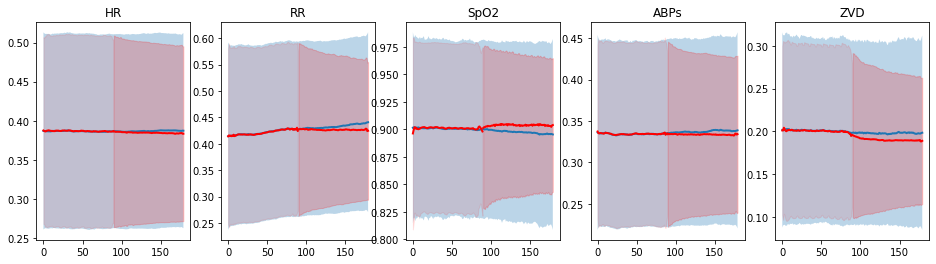

In [21]:
fig, ax = plt.subplots(1, 5, figsize=(16,4), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]



data = np.concatenate(data_raw, axis=0)
mean_raw = np.nanmean(data, axis=0)
std_raw = np.nanstd(data, axis=0)

pred = np.concatenate(data_pred, axis=0)
mean = pred.mean(0)
std = pred.std(0)
for j, physio in enumerate(physio_plot):
    idx_physio = PHYSIO_BENCHMARK.index(physio)


    ax[j].plot(mean_raw[:,idx_physio], linewidth=2);
    ax[j].fill_between(range(180), 
                    mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                    mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                    alpha=.3)

    ax[j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
    ax[j].fill_between(range(90), 
                    mean[:90,idx_physio]-std[:90,idx_physio], 
                    mean[:90,idx_physio]+std[:90,idx_physio], 
                    alpha=.1, color='r')

    ax[j].plot(range(90,180), mean[90:,idx_physio], linewidth=2, color='r');
    ax[j].fill_between(range(90, 180), 
                    mean[90:,idx_physio]-std[90:,idx_physio], 
                    mean[90:,idx_physio]+std[90:,idx_physio], 
                    alpha=.2, color='r')


#     ax.set_ylim(0.2, 0.4)
    ax[j].set_title(f'{physio}')

# AE Output for possitive samples

In [4]:
DATA = load_train_test_dataset(
        batchsize=64,
        sample_dict_file='sample_dict_vasopressor_filtered80.p',
        type='vaso',
        RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True,
        data_path=data_path
    )
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
loader_train = DATA['loader_train']
loader_val = DATA['loader_val']
loader_test = DATA['loader_test']

Loading dataset
SAMPLE TRAIN: 1758, SAMPLE VAL: 440, SAMPLE TEST: 550


In [26]:
X_reconstructed = []
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model_tcn(X)
    X_reconstructed.append(X_.cpu().detach().numpy())
    X_pred.append(X_next.cpu().detach().numpy())
    
X_reconstructed = np.concatenate(X_reconstructed, axis=0)
X_pred = np.concatenate(X_pred, axis=0)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:13<00:00,  1.51s/it]


In [24]:
from utils.data_io import pickle_load

In [28]:
sample_dict_vaso = pickle_load(os.path.join(data_path, 'sample_dict_vasopressor_filtered80.p'))

med_label, pid, t_start, t_end = sample_dict_vaso[5]
df = pickle.load(open(os.path.join('processed-merge/merged_data_per_pat', f"{pid}.p"), 'rb'))
sample = df.loc[(df.index>=t_start) & (df.index<t_end)]
data = sample[selected_physio]

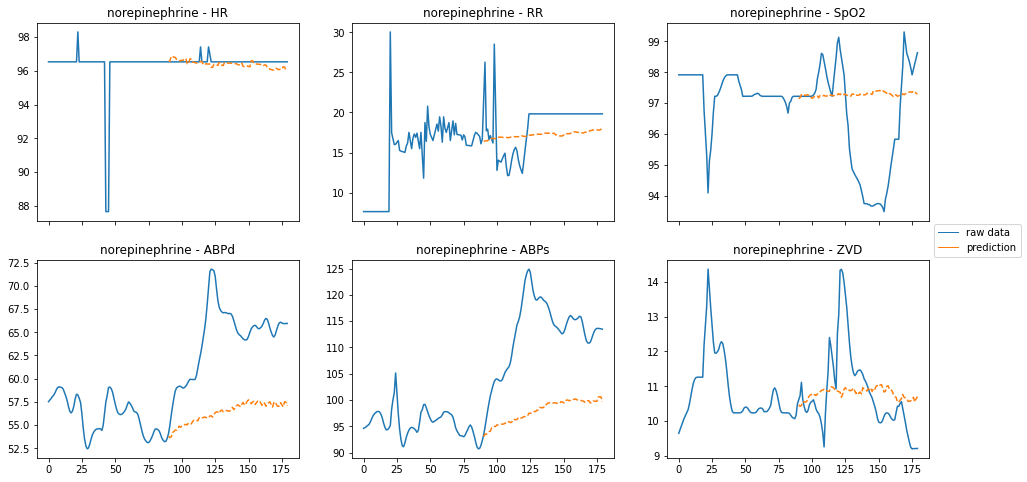

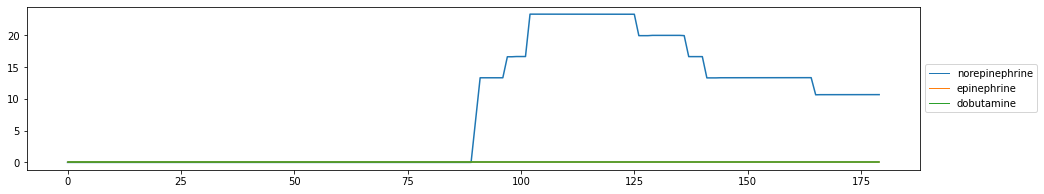

In [39]:
idx = 200


x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
meds = ['dobutamine', 'epinephrine', 'norepinephrine']
try:
    med = meds[np.where(dataset_test[idx]['med_label']==1)[0].item()]
except:
    med = None
x_med = dataset_test[idx]['med']
x_med[np.where(x_med==0)] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPd',
    'ABPs',
    'ZVD',
]
for i, physio in enumerate(physio_plot):
    idx_physio = PHYSIO_BENCHMARK.index(physio)
    
    x_raw = de_norm(x[:,idx_physio], physio)
    x_pred = de_norm(x_next[:,idx_physio], physio)
    
    ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
    ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
    ax[i//3][i%3].set_title(f"{med} - {physio}")
lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
         Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1));    

    
fig, ax = plt.subplots(1, 1, figsize=(16,3))
lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax.plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

In [31]:
meds = ['dobutamine', 'epinephrine', 'norepinephrine']

data_raw = {med: [] for med in meds}
data_pred = {med: [] for med in meds}
for idx, sample in tqdm(enumerate(dataset_test)):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw[med].append(raw[None,:,:])
    data_pred[med].append(np.concatenate((X_reconstructed[idx], X_pred[idx]), axis=0)[None,:,:])

550it [01:03,  8.68it/s]


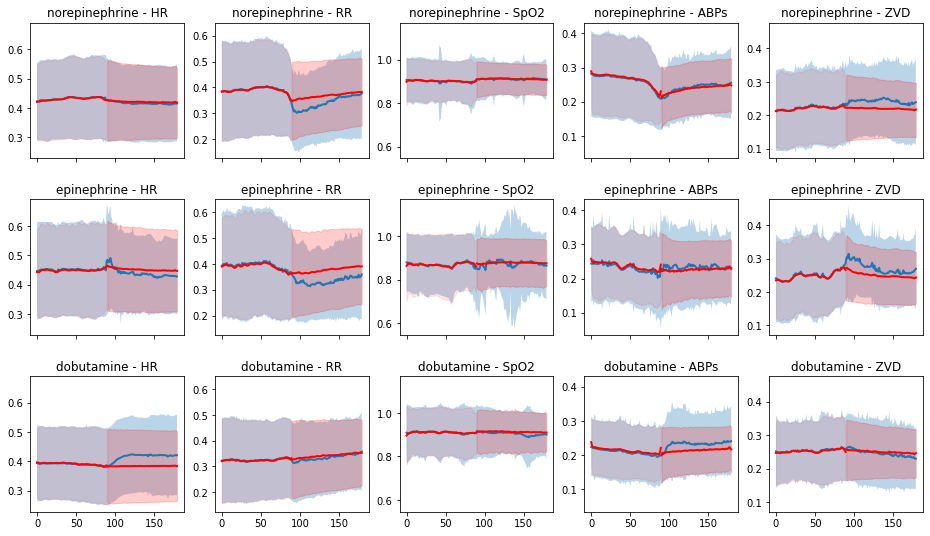

In [32]:
fig, ax = plt.subplots(3, 5, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    for j, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i][j].plot(mean_raw[:,idx_physio], linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                        mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                        alpha=.3)
        
        ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90), 
                        mean[:90,idx_physio]-std[:90,idx_physio], 
                        mean[:90,idx_physio]+std[:90,idx_physio], 
                        alpha=.1, color='r')
        
        ax[i][j].plot(range(90,180), mean[90:,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90, 180), 
                        mean[90:,idx_physio]-std[90:,idx_physio], 
                        mean[90:,idx_physio]+std[90:,idx_physio], 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

# MONO MED-Response model with pretrained AE

In [4]:
from utils.data_io import pickle_load

In [5]:
model_path_med_mono = 'models/MED_PHYSIO_MONO/TCN-168hidden-0.1dropout-8-0.0005/version_1'
for file in os.listdir(model_path_med_mono):
    if '.ckpt' in file and 'val_loss' in file:
        model_file_med_mono = file
model_file_med_mono = os.path.join(model_path_med_mono, model_file_med_mono)
config_file_med_mono = os.path.join(model_path_med_mono, "model_config.p")
config_med_mono = pickle.load(open(config_file_med_mono, 'rb'))

device = 'cuda'
model_mono = MED_PHYSIO_MONO.load_from_checkpoint(checkpoint_path=model_file_med_mono, config=config_med_mono)
model_mono.to(device)
model_mono.eval()

batchsize=32

DATA = load_train_test_dataset(
    batchsize=batchsize,
    sample_dict_file='sample_dict_vasopressor_filtered80.p',
    type='vaso',
    RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True,
    data_path=data_path
)
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
loader_train = DATA['loader_train']
loader_val = DATA['loader_val']
loader_test = DATA['loader_test']

Loading dataset
SAMPLE TRAIN: 1758, SAMPLE VAL: 440, SAMPLE TEST: 550


In [7]:
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_next = model_mono(X)
    X_pred.append(X_next.cpu().detach().numpy())

X_pred = np.concatenate(X_pred, axis=0)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:19<00:00,  1.07s/it]


In [8]:
meds = ['norepinephrine', 'epinephrine', 'dobutamine']

data_raw = {med: [] for med in meds}
data_pred = {med: [] for med in meds}
for idx, sample in tqdm(enumerate(dataset_test)):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw[med].append(raw[None,:,:])
    data_pred[med].append(X_pred[idx][None,:,:])

550it [01:32,  5.95it/s]


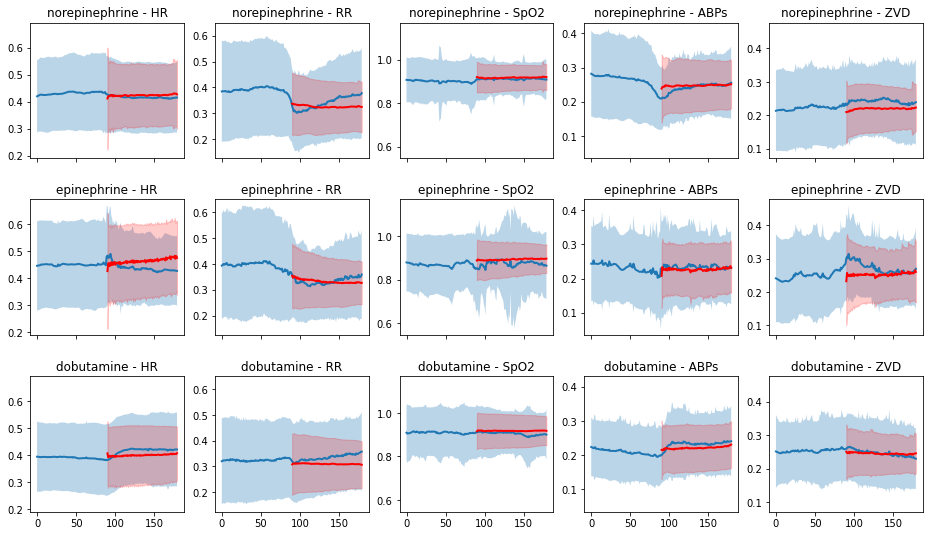

In [9]:
fig, ax = plt.subplots(3, 5, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    for j, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i][j].plot(mean_raw[:,idx_physio], linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                        mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                        alpha=.3)
        
#         ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
#         ax[i][j].fill_between(range(90), 
#                         mean[:90,idx_physio]-std[:90,idx_physio], 
#                         mean[:90,idx_physio]+std[:90,idx_physio], 
#                         alpha=.1, color='r')
        
        ax[i][j].plot(range(90,180), mean[:,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90, 180), 
                        mean[:,idx_physio]-std[:,idx_physio], 
                        mean[:,idx_physio]+std[:,idx_physio], 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

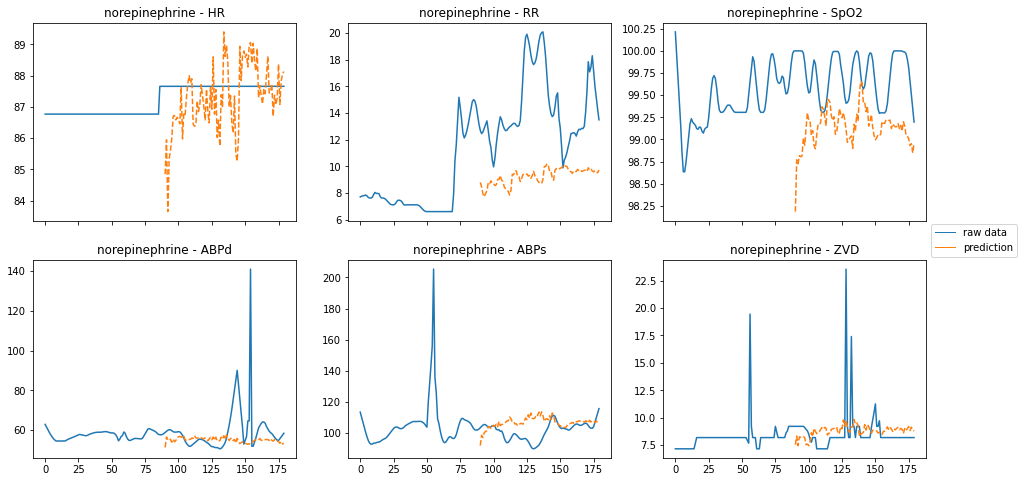

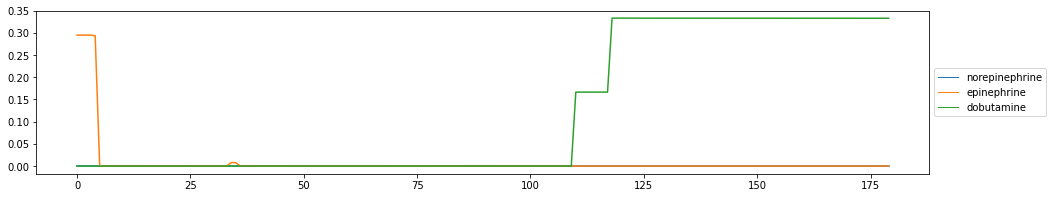

In [10]:
idx = 321


x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
meds = ['dobutamine', 'epinephrine', 'norepinephrine']
try:
    med = meds[np.where(dataset_test[idx]['med_label']==1)[0].item()]
except:
    med = None
x_med = dataset_test[idx]['med']
x_med[np.where(x_med==0)] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPd',
    'ABPs',
    'ZVD',
]
for i, physio in enumerate(physio_plot):
    idx_physio = PHYSIO_BENCHMARK.index(physio)
    
    x_raw = de_norm(x[:,idx_physio], physio)
    x_pred = de_norm(x_next[:,idx_physio], physio)
    
    ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
    ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
    ax[i//3][i%3].set_title(f"{med} - {physio}")
lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
         Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1));    

    
fig, ax = plt.subplots(1, 1, figsize=(16,3))
lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax.plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

# Iterative model

In [12]:
from utils.ClassMonoModel import MED_ITERATIVE_MONO

In [60]:
def norm_numeric_data(data_num):
    COLS = data_num.columns
    for col in COLS:
#         print(col)
        data_num.loc[data_num[col] > norm_params[col].loc['99.9%'], col] = norm_params[col].loc['99.9%']
        data_num.loc[data_num[col] < norm_params[col].loc['0.1%']] = norm_params[col].loc['0.1%']
    data_num = (data_num - norm_params[COLS].loc['0.1%']) / (norm_params[COLS].loc['99.9%'] - norm_params[COLS].loc['0.1%'])

    return data_num

In [17]:
model_path_med_mono = 'models/MED_ITERATIVE_MONO/1input-35mono-3step-15-nedstep-0.1dropout-8-0.0005/version_0/'
for file in os.listdir(model_path_med_mono):
    if '.ckpt' in file and 'val_loss' in file:
        model_file_med_mono = file
model_file_med_mono = os.path.join(model_path_med_mono, model_file_med_mono)
config_file_med_mono = os.path.join(model_path_med_mono, "model_config.p")
config_med_mono = pickle.load(open(config_file_med_mono, 'rb'))

device = 'cuda'
model_iter = MED_ITERATIVE_MONO.load_from_checkpoint(checkpoint_path=model_file_med_mono, config=config_med_mono)
model_iter.to(device)
model_iter.eval()

batchsize=32

DATA = load_train_test_dataset(
    batchsize=batchsize,
    sample_dict_file='sample_dict_vasopressor_filtered80.p',
    type='vaso',
    RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True,
    data_path=data_path
)
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
loader_train = DATA['loader_train']
loader_val = DATA['loader_val']
loader_test = DATA['loader_test']

Loading dataset
SAMPLE TRAIN: 1758, SAMPLE VAL: 440, SAMPLE TEST: 550


In [18]:
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_next = model_iter(X)
    X_pred.append(X_next.cpu().detach().numpy())

X_pred = np.concatenate(X_pred, axis=0)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:16<00:00,  1.07it/s]


In [20]:
X_pred[0].shape

(163,)

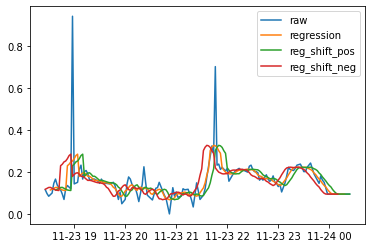

In [84]:
idx = 5
n_step = 7
col = 'ABPs'

sample_dict_vaso = pickle_load(os.path.join(data_path, 'sample_dict_vasopressor_filtered80.p'))
med, pid, t_start, t_end = sample_dict_vaso[1]

df = pickle.load(open(os.path.join('processed-merge/merged_data_per_pat', f"{pid}.p"), 'rb'))
# time-series vital sign
sample = df.loc[(df.index>=t_start) & (df.index<t_end)]

data = norm_numeric_data(sample[selected_physio])
data.interpolate(method='linear', limit_area='inside', inplace=True)
data.interpolate('ffill', inplace=True)
data.interpolate('bfill', inplace=True)
data.fillna(.5, inplace=True)

data_reg = data.rolling(n_step, center=True).mean()

plt.plot(data[col], label='raw')
plt.plot(data_reg[col], label='regression')
plt.plot(data_reg[col].shift(n_step//2), label='reg_shift_pos')
plt.plot(data_reg[col].shift(-n_step//2), label='reg_shift_neg')
plt.legend()

In [80]:
data['ABPs']

2124-11-23 18:25:45.070    0.115090
2124-11-23 18:27:45.070    0.097187
2124-11-23 18:29:45.070    0.084399
2124-11-23 18:31:45.070    0.092072
2124-11-23 18:33:45.070    0.099744
                             ...   
2124-11-24 00:15:45.070    0.094629
2124-11-24 00:17:45.070    0.094629
2124-11-24 00:19:45.070    0.094629
2124-11-24 00:21:45.070    0.094629
2124-11-24 00:23:45.070    0.094629
Freq: 2T, Name: ABPs, Length: 180, dtype: float64

In [83]:
bp = data['ABPs']
bp.rolling(3, center=True).sum()

2124-11-23 18:25:45.070         NaN
2124-11-23 18:27:45.070    0.296675
2124-11-23 18:29:45.070    0.273657
2124-11-23 18:31:45.070    0.276215
2124-11-23 18:33:45.070    0.337596
                             ...   
2124-11-24 00:15:45.070    0.283887
2124-11-24 00:17:45.070    0.283887
2124-11-24 00:19:45.070    0.283887
2124-11-24 00:21:45.070    0.283887
2124-11-24 00:23:45.070         NaN
Freq: 2T, Name: ABPs, Length: 180, dtype: float64

In [ ]:
data_reg[col].iloc[10:15].shift[]

In [22]:
meds = ['norepinephrine', 'epinephrine', 'dobutamine']

data_raw = {med: [] for med in meds}
data_pred = {med: [] for med in meds}
for idx, sample in tqdm(enumerate(dataset_test)):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw[med].append(raw[None,:,4])
    data_pred[med].append(X_pred[idx][None,:])

550it [01:43,  5.34it/s]


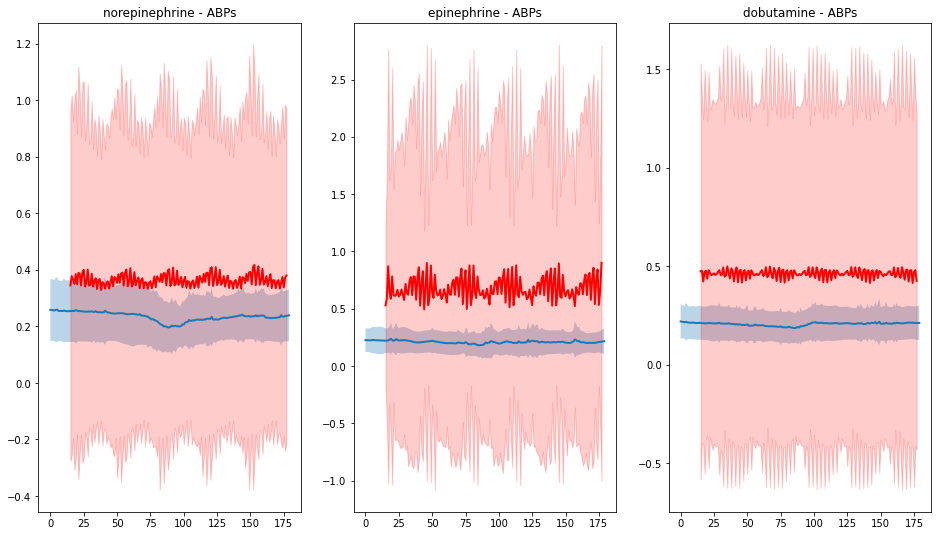

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    
    for j, physio in enumerate(['ABPs']):
#         idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i].plot(mean_raw, linewidth=2);
        ax[i].fill_between(range(180), 
                        mean_raw-std_raw, 
                        mean_raw+std_raw, 
                        alpha=.3)
        
#         ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
#         ax[i][j].fill_between(range(90), 
#                         mean[:90,idx_physio]-std[:90,idx_physio], 
#                         mean[:90,idx_physio]+std[:90,idx_physio], 
#                         alpha=.1, color='r')
        
        ax[i].plot(range(15,178), mean, linewidth=2, color='r');
        ax[i].fill_between(range(15,178), 
                        mean-std, 
                        mean+std, 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i].set_title(f'{med} - {physio}')

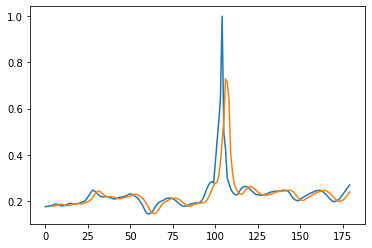

In [34]:
plt.plot(dataset_test[idx]['data'][:,4])
plt.plot(dataset_test[idx]['data_regression'][:,4])

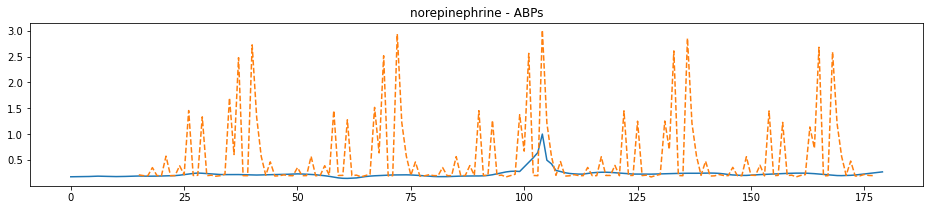

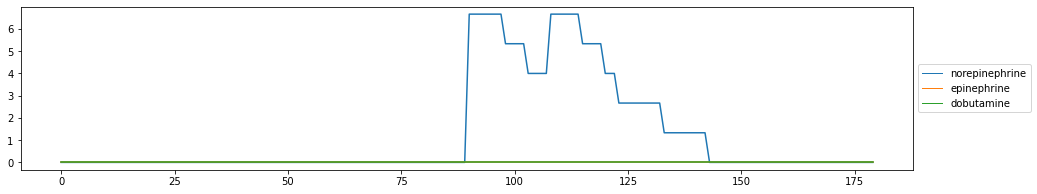

In [30]:
idx = 156


x = dataset_test[idx]['data'][:,4]
x[np.where(x==-1)] = np.nan
x_next = X_pred[idx]
x_next[np.where(x_next==-1)] = np.nan
meds = ['norepinephrine', 'epinephrine', 'dobutamine']
try:
    med = meds[np.where(dataset_test[idx]['med_label']==1)[0].item()]
except:
    med = None
x_med = dataset_test[idx]['med']
x_med[np.where(x_med==0)] = np.nan

labels = selected_physio

fig, ax = plt.subplots(1,1,figsize=(16,3), sharex=True)
colors = plt.cm.tab10
physio_plot = [
    'ABPs',
]

x_raw = x
x_pred = x_next

ax.plot(range(180), x_raw, '-', color=colors(0))
ax.plot(range(15, 178), x_pred, '--', color=colors(1))
ax.set_title(f"{med} - {physio}")
# lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
#          Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
# plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1));    

    
fig, ax = plt.subplots(1, 1, figsize=(16,3))
lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax.plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));

# Model with data smoothing, interpolation, and medication stratification

In [4]:
model_path = 'models/VASO_PHYSIO_PRED/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_5/'
model_file = os.path.join(model_path, "epoch44-val_loss_pred0.05552.ckpt")
config_file = os.path.join(model_path, "model_config.p")
config = pickle.load(open(config_file, 'rb'))

device = 'cuda'

DATA = load_train_test_dataset(
        batchsize=config['batchsize'],
        sample_dict_file='sample_dict_vasopressor_filtered70.p',
        RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True)
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
loader_train = DATA['loader_train']
loader_val = DATA['loader_val']
loader_test = DATA['loader_test']
del DATA

# Train model


model = VASO_PHYSIO_PRED.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.to(device)
model.eval()

X_reconstructed = []
X_pred = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model(X)
    X_reconstructed.append(X_.cpu().detach().numpy())
    X_pred.append(X_next.cpu().detach().numpy())
    
X_reconstructed = np.concatenate(X_reconstructed, axis=0)
X_pred = np.concatenate(X_pred, axis=0)

FileNotFoundError: [Errno 2] No such file or directory: 'models/VASO_PHYSIO_PRED/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_5/model_config.p'

('norepinephrine', <Figure size 1152x216 with 1 Axes>)

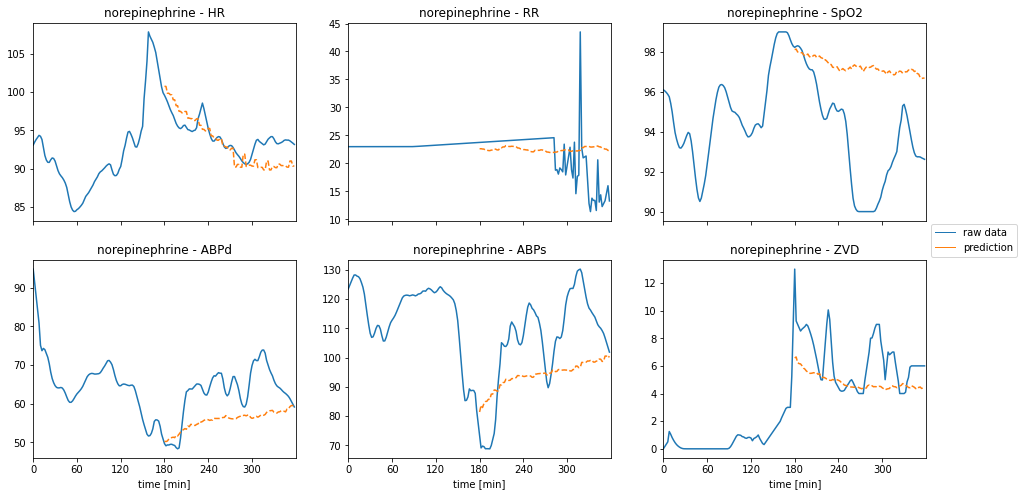

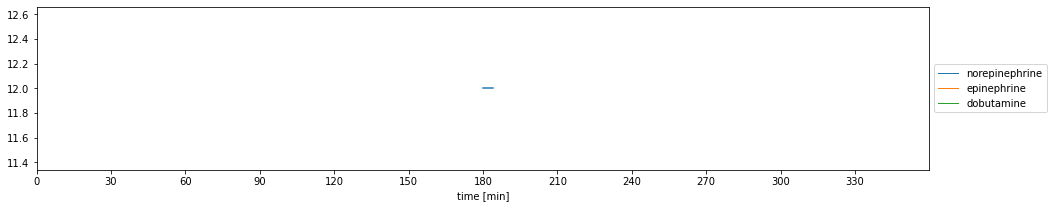

In [14]:
# plot_vital_pred(333)
plot_vital_pred(333)

In [39]:
dataset_test[333]['med']

array([[-2.79098137e-06, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [-2.79098137e-06, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [-2.79098137e-06, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       ...,
       [ 2.39737432e-02, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [ 2.39737432e-02, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05],
       [ 2.39737432e-02, -1.70346087e-06, -1.81851242e-04, ...,
        -3.34437611e-03, -1.99702973e-06, -1.04167752e-05]])

100%|█| 697/697 [01:18<00:0


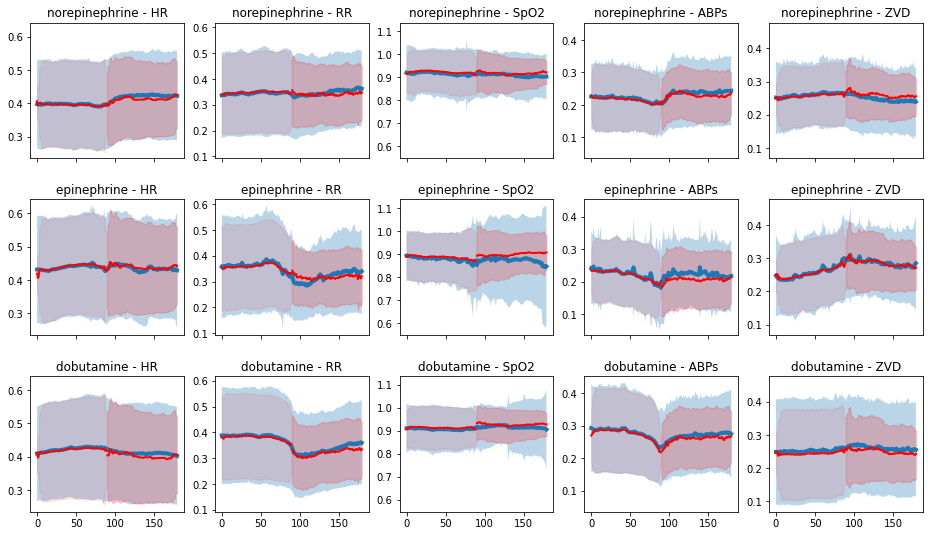

In [36]:
meds = ['dobutamine', 'epinephrine', 'norepinephrine']

data_raw = {med: [] for med in meds}
data_pred = {med: [] for med in meds}
for idx, sample in enumerate(tqdm(dataset_test)):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw[med].append(raw[None,:,:])
    data_pred[med].append(np.concatenate((X_reconstructed[idx], X_pred[idx]), axis=0)[None,:,:])


fig, ax = plt.subplots(3, 5, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPs',
    'ZVD',
#     'OUTurine/h',
]


for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    for j, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i][j].plot(mean_raw[:,idx_physio], linewidth=4);
        ax[i][j].fill_between(range(180), 
                        mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                        mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                        alpha=.3)
        
        ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90), 
                        mean[:90,idx_physio]-std[:90,idx_physio], 
                        mean[:90,idx_physio]+std[:90,idx_physio], 
                        alpha=.1, color='r')
        
        ax[i][j].plot(range(90,180), mean[90:,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90, 180), 
                        mean[90:,idx_physio]-std[90:,idx_physio], 
                        mean[90:,idx_physio]+std[90:,idx_physio], 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

# Save plots

In [171]:
save_path = 'plots/vasoactive_agents/'

for idx in tqdm(range(len(dataset_test))):
    med, fig = gridplot_vital_pred(idx)
    save_to = os.path.join(save_path, med)
    Path(save_to).mkdir(parents=True, exist_ok=True)
    fig.savefig(os.path.join(save_to, f'{idx}.png'),  dpi=600, bbox_inches='tight')
    plt.close(fig)

100%|█| 697/697 [44:11<00:0


('norepinephrine', <Figure size 1152x720 with 7 Axes>)

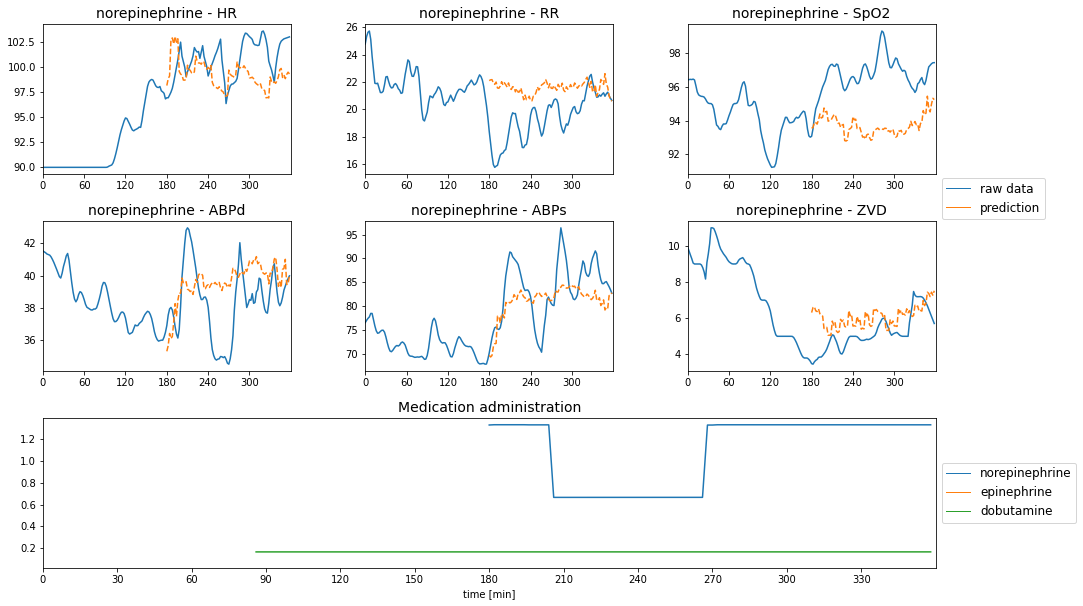

In [173]:
gridplot_vital_pred(89)

# Response to different medication dosage 

In [11]:
from copy import deepcopy

In [12]:
len(data_raw['norepinephrine']), len(data_raw['epinephrine']), len(data_raw['dobutamine'])

(416, 97, 285)

100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  9.72it/s]


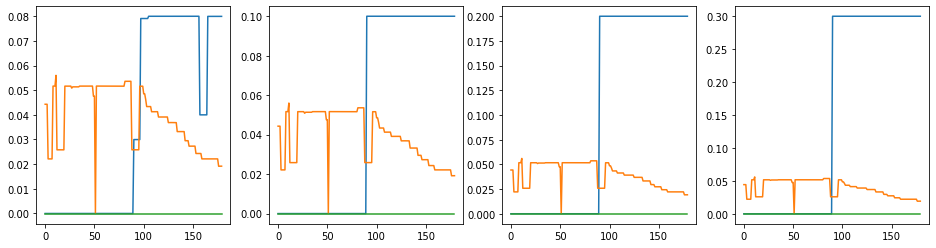

In [20]:
idx = 222

sample = dataset_test[idx]

sample1 =  deepcopy(sample)
sample1['med'][90:, 0] = 0.1

sample2 =  deepcopy(sample)
sample2['med'][90:, 0] = 0.2

sample3 =  deepcopy(sample)
sample3['med'][90:, 0] = 0.3

samples = [sample1, sample2, sample3]

fig, ax = plt.subplots(1, 4, figsize=(16,4))
ax[0].plot(sample['med'][:,:3])
for i in range(3):
    ax[i+1].plot(samples[i]['med'][:,:3])

loader = DataLoader(samples)

reconsts = []
preds = []
for X in tqdm(loader):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    X_, X_next = model(X)
    reconsts.append(X_.cpu().detach().numpy())
    preds.append(X_next.cpu().detach().numpy())
    
reconsts = np.concatenate(reconsts, axis=0)
preds = np.concatenate(preds, axis=0)



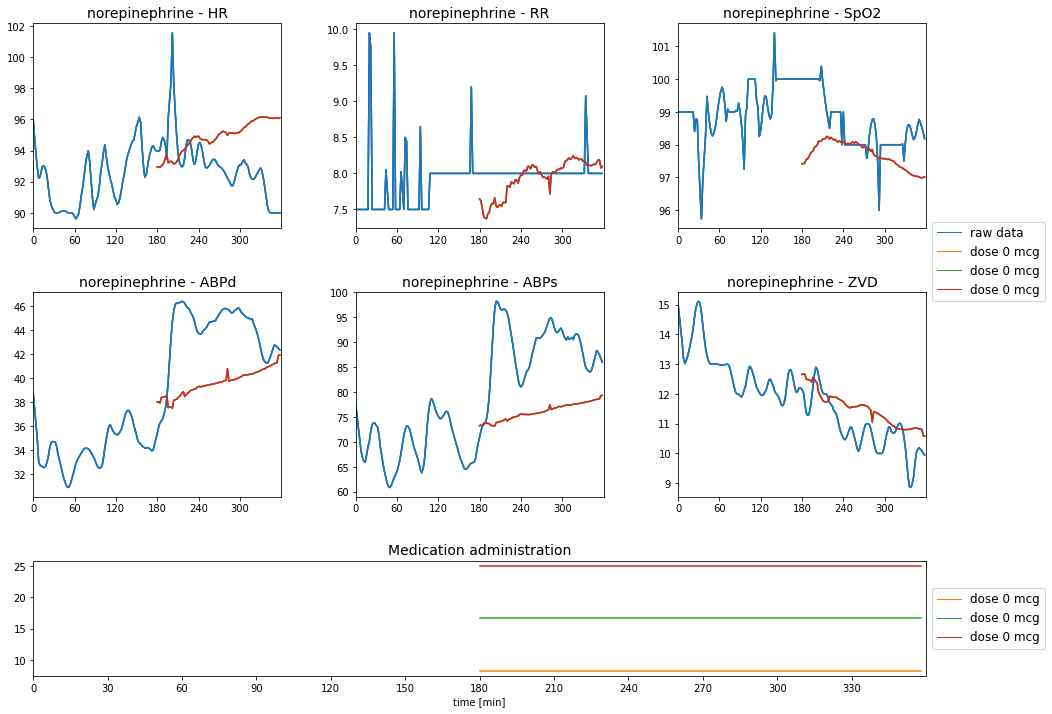

In [21]:
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(8,3)
ax = []
for i in range(6):
    if i == 0:
        ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
    else:
        ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
ax.append(fig.add_subplot(gs[6:,:]))

colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'SpO2',
    'ABPd',
    'ABPs',
    'ZVD',
]

legends = []
for j in range(3):
    legends.append(f"dose {round(de_norm(samples[j]['med'][:,0], med)[-1])} mcg")

for i, physio in enumerate(physio_plot):
    for j in range(3):
        idx_physio = PHYSIO_BENCHMARK.index(physio)

        sample = samples[j]
        x = sample['data']
        x[np.where(x==-1)] = np.nan
        x_ = X_reconstructed[idx]
        x_[np.where(x_==-1)] = np.nan
        x_next = preds[j]
        x_next[np.where(x_next==-1)] = np.nan

        x_raw = de_norm(x[:,idx_physio], physio)
        x_pred = de_norm(x_next[:,idx_physio], physio)
        med_label = 'norepinephrine'

        ax[i].plot(range(180), x_raw, '-', color=colors(0))
        ax[i].plot(range(90, 180), x_pred, '-', color=colors(j+1))
        ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
         Line2D([0], [0], color=colors(1), lw=1, label=legends[0]),
         Line2D([0], [0], color=colors(2), lw=1, label=legends[1]),
         Line2D([0], [0], color=colors(3), lw=1, label=legends[2])]
ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
ax[5].set_xlim([0, 180])
ax[5].set_xticks(np.arange(0, 180, 30))
ax[5].set_xticklabels(np.arange(0, 360, 60))


lines = []
med = 'norepinephrine'
for j in range(3):
    x_med = samples[j]['med']
#     x_med[np.where(x_med==0)] = np.nan

    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    med_raw[np.where(med_raw==0)] = np.nan
    ax[6].plot(med_raw, label=med, color=colors(j+1))
    lines.append(Line2D([0], [0], color=colors(j+1), lw=1, label=legends[j]))
ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
ax[6].set_xlim([0, 180])
ax[6].set_xticks(np.arange(0, 180, 15))
ax[6].set_xticklabels(np.arange(0, 360, 30))
ax[6].set_xlabel('time [min]')
ax[6].set_title('Medication administration', fontsize=14)

plt.subplots_adjust(hspace=2.5, wspace=.3)

In [22]:
preds.shape

(3, 90, 7)

In [26]:
preds[1, :, 1] - preds[0, :, 1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.], dtype=float32)

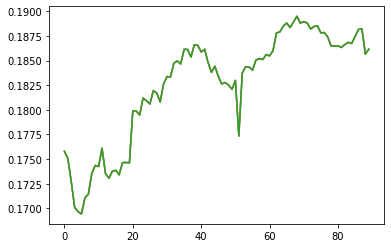

In [25]:
plt.plot(preds[:, :, 1].T);

In [12]:
savepath = 'plots/vasoactive_agents/dosage_response_mono'
Path(savepath).mkdir(parents=True, exist_ok=True)

for idx in tqdm(range(100)):
    sample = dataset_test[idx]
    sample1 =  deepcopy(sample)
    sample1['med'][90:, 0] = 0.01
    sample2 =  deepcopy(sample)
    sample2['med'][90:, 0] = 0.02
    sample3 =  deepcopy(sample)
    sample3['med'][90:, 0] = 0.05
    samples = [sample1, sample2, sample3]
    loader = DataLoader(samples)

    reconsts = []
    preds = []
    for X in loader:
        for k in X:
            if type(X[k]) is dict:
                for j in X[k]:
                    X[k][j] = X[k][j].to(device)
            else:
                X[k] = X[k].to(device)
        X_, X_next = model(X)
        reconsts.append(X_.cpu().detach().numpy())
        preds.append(X_next.cpu().detach().numpy())

    reconsts = np.concatenate(reconsts, axis=0)
    preds = np.concatenate(preds, axis=0)



    labels = selected_physio

    fig = plt.figure(figsize=(16,12))
    gs = fig.add_gridspec(8,3)
    ax = []
    for i in range(6):
        if i == 0:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
        else:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
    ax.append(fig.add_subplot(gs[6:,:]))

    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]

    legends = []
    for j in range(3):
        legends.append(f"dose {round(de_norm(samples[j]['med'][:,0], med)[-1])} mcg")

    for i, physio in enumerate(physio_plot):
        for j in range(3):
            idx_physio = PHYSIO_BENCHMARK.index(physio)

            sample = samples[j]
            x = sample['data']
            x[np.where(x==-1)] = np.nan
            x_ = X_reconstructed[idx]
            x_[np.where(x_==-1)] = np.nan
            x_next = preds[j]
            x_next[np.where(x_next==-1)] = np.nan

            x_raw = de_norm(x[:,idx_physio], physio)
            x_pred = de_norm(x_next[:,idx_physio], physio)
            med_label = 'norepinephrine'

            ax[i].plot(range(180), x_raw, '-', color=colors(0))
            ax[i].plot(range(90, 180), x_pred, '-', color=colors(j+1))
            ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label=legends[0]),
             Line2D([0], [0], color=colors(2), lw=1, label=legends[1]),
             Line2D([0], [0], color=colors(3), lw=1, label=legends[2])]
    ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
    ax[5].set_xlim([0, 180])
    ax[5].set_xticks(np.arange(0, 180, 30))
    ax[5].set_xticklabels(np.arange(0, 360, 60))


    lines = []
    med = 'norepinephrine'
    for j in range(3):
        x_med = samples[j]['med']
    #     x_med[np.where(x_med==0)] = np.nan

        idx_med = MED_BENCHMARK.index(med)
        med_raw =  de_norm(x_med[:, idx_med], med)
        med_raw[np.where(med_raw==0)] = np.nan
        ax[6].plot(med_raw, label=med, color=colors(j+1))
        lines.append(Line2D([0], [0], color=colors(j+1), lw=1, label=legends[j]))
    ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
    ax[6].set_xlim([0, 180])
    ax[6].set_xticks(np.arange(0, 180, 15))
    ax[6].set_xticklabels(np.arange(0, 360, 30))
    ax[6].set_xlabel('time [min]')
    ax[6].set_title('Medication administration', fontsize=14)

    plt.subplots_adjust(hspace=2.5, wspace=.3)
    
    fig.savefig(os.path.join(savepath, f"{idx}.png"), dpi=600, bbox_inches='tight')
    plt.close(fig)

100%|█████████████████████████████████████████████████████████████████████| 100/100 [07:07<00:00,  4.28s/it]


In [235]:
for j in range(3):
    print(de_norm(samples[j]['med'][:,0], med)[-1])

0.8334811673299529
1.666729776525569
4.166475604112417


In [ ]:
sample['med'].shapee

In [255]:
med_ = []

for sample in tqdm(dataset_test):
    med_label = sample['med_label']
    med_.append(sample['med'])

100%|█| 697/697 [01:19<00:0


In [265]:
med_statistics = np.array(med_)
med_statistics[np.where(med_statistics==0)] = np.nan

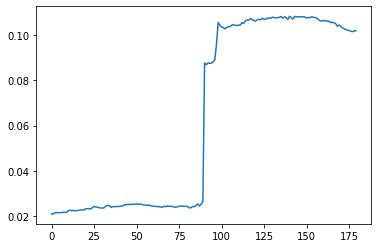

In [268]:
plt.plot(np.nanmean(med_statistics, axis=0)[:, 2])


In [15]:
data_raw['norepinephrine'].shape

AttributeError: 'list' object has no attribute 'shape'

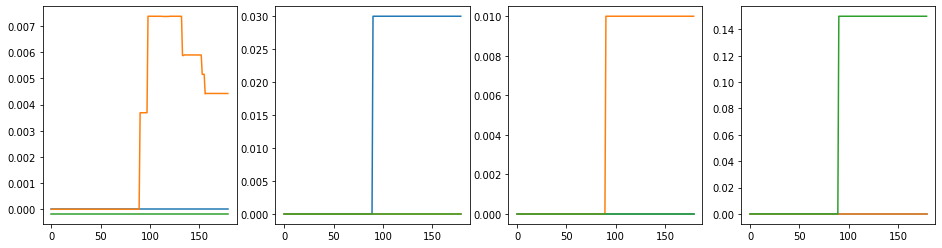

In [271]:
idx = 400

sample = dataset_test[idx]

c

samples = [sample1, sample2, sample3]

fig, ax = plt.subplots(1, 4, figsize=(16,4))
ax[0].plot(sample['med'][:,:3])
for i in range(3):
    ax[i+1].plot(samples[i]['med'][:,:3])

# loader = DataLoader(samples)

# reconsts = []
# preds = []
# for X in tqdm(loader):
#     for k in X:
#         if type(X[k]) is dict:
#             for j in X[k]:
#                 X[k][j] = X[k][j].to(device)
#         else:
#             X[k] = X[k].to(device)
#     X_, X_next = model(X)
#     reconsts.append(X_.cpu().detach().numpy())
#     preds.append(X_next.cpu().detach().numpy())
    
# reconsts = np.concatenate(reconsts, axis=0)
# preds = np.concatenate(preds, axis=0)



In [1]:
savepath = 'plots/vasoactive_agents/med_response'
Path(savepath).mkdir(parents=True, exist_ok=True)

for idx in tqdm(range(1)):
    sample = dataset_test[idx]
    sample1 =  deepcopy(sample)
    sample1['med'][:, :3] = 0
    sample1['med'][90:, 0] = 0.1

    sample2 =  deepcopy(sample)
    sample2['med'][:, :3] = 0
    sample2['med'][90:, 1] = 0.1

    sample3 =  deepcopy(sample)
    sample3['med'][:, :3] = 0
    sample3['med'][90:, 2] = 1

    reconsts = []
    preds = []
    for X in loader:
        for k in X:
            if type(X[k]) is dict:
                for j in X[k]:
                    X[k][j] = X[k][j].to(device)
            else:
                X[k] = X[k].to(device)
        X_, X_next = model(X)
        reconsts.append(X_.cpu().detach().numpy())
        preds.append(X_next.cpu().detach().numpy())

    reconsts = np.concatenate(reconsts, axis=0)
    preds = np.concatenate(preds, axis=0)



    labels = selected_physio

    fig = plt.figure(figsize=(16,12))
    gs = fig.add_gridspec(8,3)
    ax = []
    for i in range(6):
        if i == 0:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3]))
        else:
            ax.append(fig.add_subplot(gs[i//3*3:(i//3+1)*3, i%3], sharex=ax[0]))
    ax.append(fig.add_subplot(gs[6:,:]))

    colors = plt.cm.tab10
    physio_plot = [
        'HR',
        'RR',
        'SpO2',
        'ABPd',
        'ABPs',
        'ZVD',
    ]

    legends = MED_BENCHMARK[:3]
    for j in range(3):
        legends.append(legends[j] + f" - {round(de_norm(samples[j]['med'][:,j], med[j])[-1])} mcg")

    for i, physio in enumerate(physio_plot):
        for j in range(3):
            idx_physio = PHYSIO_BENCHMARK.index(physio)

            sample = samples[j]
            x = sample['data']
            x[np.where(x==-1)] = np.nan
            x_ = X_reconstructed[idx]
            x_[np.where(x_==-1)] = np.nan
            x_next = preds[j]
            x_next[np.where(x_next==-1)] = np.nan

            x_raw = de_norm(x[:,idx_physio], physio)
            x_pred = de_norm(x_next[:,idx_physio], physio)
            med_label = 'norepinephrine'

            ax[i].plot(range(180), x_raw, '-', color=colors(0))
            ax[i].plot(range(90, 180), x_pred, '-', color=colors(j+1))
            ax[i].set_title(f"{med_label} - {physio}", fontsize=14)
    lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
             Line2D([0], [0], color=colors(1), lw=1, label=legends[0]),
             Line2D([0], [0], color=colors(2), lw=1, label=legends[1]),
             Line2D([0], [0], color=colors(3), lw=1, label=legends[2])]
    ax[5].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.15), fontsize=12); 
    ax[5].set_xlim([0, 180])
    ax[5].set_xticks(np.arange(0, 180, 30))
    ax[5].set_xticklabels(np.arange(0, 360, 60))


    lines = []
    med = MED_BENCHMARK[:3]
    for j in range(3):
        x_med = samples[j]['med']
    #     x_med[np.where(x_med==0)] = np.nan

        idx_med = MED_BENCHMARK.index(med[j])
        med_raw =  de_norm(x_med[:, idx_med], med[j])
        med_raw[np.where(med_raw==0)] = np.nan
        ax[6].plot(med_raw, label=med[j], color=colors(j+1))
        lines.append(Line2D([0], [0], color=colors(j+1), lw=1, label=legends[j]))
    ax[6].legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12);
    ax[6].set_xlim([0, 180])
    ax[6].set_xticks(np.arange(0, 180, 15))
    ax[6].set_xticklabels(np.arange(0, 360, 30))
    ax[6].set_xlabel('time [min]')
    ax[6].set_title('Medication administration', fontsize=14)

    plt.subplots_adjust(hspace=2.5, wspace=.3)
    
    fig.savefig(os.path.join(savepath, f"{idx}.png"), dpi=600, bbox_inches='tight')
#     plt.close(fig)

NameError: name 'Path' is not defined

In [277]:
samples[j]['med']

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.34659308e-03, -1.99702973e-06, -1.04167752e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.34659308e-03, -1.99702973e-06, -1.04167752e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.34659308e-03, -1.99702973e-06, -1.04167752e-05],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  1.50000000e-01, ...,
         3.34659308e-03,  9.97577738e-03,  6.24902343e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.50000000e-01, ...,
         3.34659308e-03,  9.97577738e-03,  6.24902343e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.50000000e-01, ...,
         3.34659308e-03,  9.97577738e-03,  6.24902343e-02]])